# Machine Learning — Pertemuan 04
## Aljabar Linear, Normalisasi, Matrix & Gradient Descent | Studi Kasus Beasiswa

**Nama Mahasiswa:** Gathan Hilabi  
**NIM:** 059  
**Mata Kuliah:** Machine Learning  
**Topik:** Implementasi Aljabar Linear, Normalisasi Min-Max, Operasi Matriks, Mean Squared Error (MSE), dan Optimasi Gradient Descent untuk Sistem Penilaian Kelayakan Beasiswa

---

### Kasus Utama:
Mengolah data beberapa mahasiswa menjadi **score kelayakan beasiswa** menggunakan operasi matriks dan proses optimasi/belajar model secara mandiri (*from scratch*).

### Tiga Pilar Pembelajaran:
1. **DATA**: Representasi data fitur mahasiswa ke dalam matriks $X$ dan target kelayakan ke dalam vektor $y$.
2. **MODEL**: Transformasi skala fitur dengan Normalisasi Min-Max $\rightarrow$ perkalian matriks bobot $X_{\text{norm}} @ w \rightarrow$ prediksi skor kelayakan.
3. **BELAJAR (TRAINING)**: Evaluasi kesalahan dengan fungsi Loss (MSE) $\rightarrow$ kalkulasi arah perbaikan dengan Gradient (turunan parsial) $\rightarrow$ pembaruan bobot (*Update Weight*) menggunakan Gradient Descent secara berulang hingga konvergen.

---

### Alur Praktikum:
```text
[STEP 1-3] Data Mentah ──> Matriks X ──> Normalisasi Min-Max
                                              │
[STEP 4-6] Weight Awal ──> Prediction (X @ w) ──> Loss Function (MSE)
                                              │
[STEP 7-9] Gradient (grad_w L) ──> Update Weight ──> Training Loop
                                              │
[STEP 10-12] Monitoring ──> Data Mahasiswa Baru ──> Normalisasi & Score/Kelas
                                              │
[MODIFIKASI] Tugas 1 (3 Mhs Baru) ──> Tugas 2 (Eksperimen LR) ──> Tugas 3 (Stopping Criterion)
```


---
## Step 1 — Menyiapkan Data & Target

Pada tahap ini, kita mengonversi data mentah 5 orang mahasiswa dengan 4 fitur ke dalam matriks $X$ berdimensi $(5 \times 4)$ dan vektor target $y$ berdimensi $(5,)$.

### Definisi Fitur:
1. **Kolom 0 - Kehadiran**: Persentase kehadiran kuliah (skala 0 - 100%)
2. **Kolom 1 - IPK**: Indeks Prestasi Kumulatif (skala 0.00 - 4.00)
3. **Kolom 2 - Penghasilan**: Penghasilan orang tua (dalam satuan juta rupiah / bulan)
4. **Kolom 3 - Prestasi**: Skor capaian prestasi non-akademik/akademik (skala 0 - 100)

### Target ($y$):
* `1`: Layak menerima beasiswa
* `0`: Belum layak menerima beasiswa


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Matriks Fitur X: 5 mahasiswa x 4 fitur
X = np.array([
    [90, 3.70, 2.5, 80],
    [70, 3.20, 5.0, 60],
    [95, 3.85, 2.0, 90],
    [60, 2.90, 6.0, 50],
    [85, 3.60, 3.0, 75]
], dtype=float)

# Vektor Target y: 1 = Layak, 0 = Belum Layak
y = np.array([1, 0, 1, 0, 1], dtype=float)

print("Dimensi Matriks X :", X.shape)
print("Dimensi Vektor y  :", y.shape)
print("\nMatriks X (Data Mentah):\n", X)
print("\nVektor y (Target):\n", y)


Dimensi Matriks X : (5, 4)
Dimensi Vektor y  : (5,)

Matriks X (Data Mentah):
 [[90.    3.7   2.5  80.  ]
 [70.    3.2   5.   60.  ]
 [95.    3.85  2.   90.  ]
 [60.    2.9   6.   50.  ]
 [85.    3.6   3.   75.  ]]

Vektor y (Target):
 [1. 0. 1. 0. 1.]


### Analisis Step 1:
* $X$ terdiri dari 5 baris (mahasiswa Andi, Budi, Citra, Deni, Evi) dan 4 kolom (fitur).
* Target $y$ menunjukkan bahwa mahasiswa baris ke-0 (Andi), ke-2 (Citra), dan ke-4 (Evi) berstatus Layak (`1`), sedangkan baris ke-1 (Budi) dan ke-3 (Deni) berstatus Belum Layak (`0`).


---
## Step 2 — Normalisasi Min-Max

### Mengapa Normalisasi Diperlukan?
Fitur Kehadiran ($60-95$), IPK ($2.90-3.85$), Penghasilan ($2.0-6.0$), dan Prestasi ($50-90$) memiliki rentang dan satuan yang sangat berbeda.  
Jika tidak dinormalisasi, fitur dengan skala angka besar (seperti kehadiran dan prestasi) akan mendominasi perhitungan gradien, sehingga proses optimasi menjadi tidak stabil.

### Rumus Min-Max Normalization:
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Formula ini mentransformasikan semua nilai fitur ke dalam rentang seragam $[0, 1]$.


In [2]:
X_min = X.min(axis=0)
X_max = X.max(axis=0)

# Menerapkan rumus Min-Max Scaling
X_norm = (X - X_min) / (X_max - X_min)

print("X_min per fitur :", X_min)
print("X_max per fitur :", X_max)
print("\nMatriks X Ter-normalisasi (X_norm) [3 desimal]:\n", np.round(X_norm, 3))


X_min per fitur : [60.   2.9  2.  50. ]
X_max per fitur : [95.    3.85  6.   90.  ]

Matriks X Ter-normalisasi (X_norm) [3 desimal]:
 [[0.857 0.842 0.125 0.75 ]
 [0.286 0.316 0.75  0.25 ]
 [1.    1.    0.    1.   ]
 [0.    0.    1.    0.   ]
 [0.714 0.737 0.25  0.625]]


### Analisis Step 2:
Semua kolom kini memiliki nilai minimum $0$ dan nilai maksimum $1$. Nilai tertinggi pada tiap fitur bernilai $1.0$, sedangkan nilai terendah bernilai $0.0$.


---
## Step 3 — Verifikasi Hasil Normalisasi

Kita perlu memastikan bahwa:
1. Nilai minimum per kolom bernilai tepat $0.0$.
2. Nilai maksimum per kolom bernilai tepat $1.0$.
3. Data mahasiswa pertama (Andi) merefleksikan transformasi nilai yang tepat.

> **PENTING UNTUK DATA BARU:**  
> Saat memproses data baru/testing di masa mendatang, kita **harus menggunakan `X_min` dan `X_max` dari data training**, bukan menghitung ulang min/max dari data baru. Hal ini wajib untuk menjaga konsistensi ruang fitur (mencegah *data leakage*).


In [3]:
print("Min per kolom :", X_norm.min(axis=0))
print("Max per kolom :", X_norm.max(axis=0))
print("Andi (baris 0):", np.round(X_norm[0], 3))


Min per kolom : [0. 0. 0. 0.]
Max per kolom : [1. 1. 1. 1.]
Andi (baris 0): [0.857 0.842 0.125 0.75 ]


### Analisis Step 3:
* Andi memiliki Kehadiran $90$ (ternormalisasi menjadi $0.857$), IPK $3.70$ (ternormalisasi $0.842$), Penghasilan $2.5$ juta (ternormalisasi $0.125$), dan Prestasi $80$ (ternormalisasi $0.750$).
* Verifikasi membuktikan seluruh fitur berada persis di rentang $[0, 1]$.


---
## Step 4 — Menentukan Bobot Awal (Weight Vector)

Model linier kita memetakan fitur ternormalisasi menjadi skor dengan vektor bobot $w \in \mathbb{R}^4$:
$$w = \begin{bmatrix} w_0 \\ w_1 \\ w_2 \\ w_3 \end{bmatrix} = \begin{bmatrix} 0.35 & (\text{Kehadiran}) \\ 0.30 & (\text{IPK}) \\ -0.20 & (\text{Penghasilan}) \\ 0.25 & (\text{Prestasi}) \end{bmatrix}$$

### Interpretasi Domain Beasiswa:
* **Kehadiran ($+0.35$) & IPK ($+0.30$)**: Berbobot positif karena semakin tinggi, semakin layak mahasiswa tersebut.
* **Penghasilan ($-0.20$)**: Diberi bobot negatif sebagai ilustrasi bahwa beasiswa ini diprioritaskan bagi mahasiswa dengan kebutuhan finansial (penghasilan orang tua lebih rendah mendapatkan penalti negatif yang lebih kecil).
* **Prestasi ($+0.25$)**: Berbobot positif sebagai apresiasi prestasi mahasiswa.

*Catatan: Bobot awal ini adalah inisialisasi awal (dugaan awal manusia) dan belum optimal. Nilai bobot ini akan diperbaiki secara otomatis oleh algoritma Gradient Descent.*


In [4]:
w = np.array([
    0.35,  # Kehadiran
    0.30,  # IPK
   -0.20,  # Penghasilan
    0.25   # Prestasi
])

print("Vektor Bobot Awal (w):", w)
print("Dimensi Bobot (w)    :", w.shape)


Vektor Bobot Awal (w): [ 0.35  0.3  -0.2   0.25]
Dimensi Bobot (w)    : (4,)


---
## Step 5 — Perkalian Matriks $\times$ Bobot $\rightarrow$ Prediksi Skor

Prediksi skor diperoleh melalui perkalian matriks antara matriks fitur ternormalisasi $X_{\text{norm}}$ dan vektor bobot $w$:
$$\hat{y} = X_{\text{norm}} @ w$$

### Analisis Dimensi Aljabar Linear:
$$X_{\text{norm}} (5 \times 4) \times w (4 \times 1) \longrightarrow \hat{y} (5 \times 1)$$
Operasi ini menghasilkan 1 nilai skor prediksi untuk setiap mahasiswa.


In [5]:
# Perkalian matriks menggunakan operator @
y_pred = X_norm @ w

print("Score Prediksi Awal (y_pred):")
print(np.round(y_pred, 3))

# Tampilkan per mahasiswa
nama_mhs = ["Andi", "Budi", "Citra", "Deni", "Evi"]
for nama, skor, target in zip(nama_mhs, y_pred, y):
    print(f"- {nama:<6}: Skor Prediksi = {skor:.3f} | Target Aktual = {int(target)}")


Score Prediksi Awal (y_pred):
[ 0.715  0.107  0.9   -0.2    0.577]
- Andi  : Skor Prediksi = 0.715 | Target Aktual = 1
- Budi  : Skor Prediksi = 0.107 | Target Aktual = 0
- Citra : Skor Prediksi = 0.900 | Target Aktual = 1
- Deni  : Skor Prediksi = -0.200 | Target Aktual = 0
- Evi   : Skor Prediksi = 0.577 | Target Aktual = 1


### Analisis Step 5:
* Andi ($0.715$), Citra ($0.900$), dan Evi ($0.577$) memiliki skor positif tinggi mendekati target $1$.
* Namun Budi ($0.107$) dan Deni ($-0.200$) masih memiliki gap kesalahan terhadap target aktual mereka.


---
## Step 6 — Menghitung Error dan Loss Function (MSE)

### 1. Error Residual:
Selisih antara nilai prediksi model $\hat{y}$ dengan nilai target sebenarnya $y$:
$$e = \hat{y} - y$$

### 2. Loss Function (Mean Squared Error - MSE):
Ukuran ringkas rata-rata kuadrat kesalahan seluruh data latih:
$$L(w) = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2 = \frac{1}{N} \|X_{\text{norm}} w - y\|^2$$

**Tujuan Training:** Menemukan kombinasi nilai bobot $w$ yang meminimalkan nilai $L(w)$.


In [6]:
error = y_pred - y
loss = np.mean(error ** 2)

print("Error Residual per Mahasiswa:", np.round(error, 3))
print("Loss (Mean Squared Error)   :", round(loss, 6))


Error Residual per Mahasiswa: [-0.285  0.107 -0.1   -0.2   -0.423]
Loss (Mean Squared Error)   : 0.064265


### Analisis Step 6:
* Nilai loss awal dengan bobot intuitif adalah **0.064265**.
* Loss ini merefleksikan akumulasi ketidaktepatan prediksi model terhadap label kelayakan sebenarnya.


---
## Step 7 — Menghitung Gradient (Turunan Parsial Loss)

### Penurunan Matematis Gradient:
Loss didefinisikan sebagai:
$$L(w) = \frac{1}{N} (X w - y)^T (X w - y)$$

Dengan aturan rantai kalkulus matriks, turunan parsial terhadap vektor $w$ adalah:
$$\nabla_w L = \frac{\partial L}{\partial w} = \frac{2}{N} X_{\text{norm}}^T (X_{\text{norm}} w - y) = \frac{2}{N} X_{\text{norm}}^T e$$

### Analisis Dimensi Aljabar Linear:
$$X_{\text{norm}}^T (4 \times 5) \times e (5 \times 1) \longrightarrow \nabla_w L (4 \times 1)$$

Gradient menunjukkan **arah perubahan tercuram** dari kenaikan fungsi loss. Oleh karena itu, kita harus menggeser bobot ke arah **sebaliknya (negatif gradient)** untuk menurunkan loss.


In [7]:
# Menghitung gradien bobot
gradient = (2 / len(X_norm)) * (X_norm.T @ error)

print("Gradient (grad_w L):")
print(np.round(gradient, 6))


Gradient (grad_w L):
[-0.246184 -0.246994 -0.104342 -0.220411]


### Analisis Step 7:
* Nilai gradient mengindikasikan seberapa besar dan ke arah mana bobot setiap fitur harus digeser.
* Nilai gradien negatif berarti menaikkan bobot tersebut akan mengurangi loss, sedangkan gradien positif berarti menurunkan bobot tersebut akan mengurangi loss.


---
## Step 8 — Update Weight (Pembaruan Bobot)

Aturan pembaruan bobot dalam algoritma Gradient Descent:
$$w_{\text{baru}} = w_{\text{lama}} - \alpha \times \nabla_w L$$

Di mana:
* $\alpha$ (*learning rate*) = faktor pengali yang menentukan besar langkah update (di sini $\alpha = 0.1$).
* Model menggeser nilai bobot sedikit demi sedikit menuju titik optimal.


In [8]:
learning_rate = 0.1
w_baru = w - learning_rate * gradient

print("Bobot Lama (w_lama):", np.round(w, 4))
print("Bobot Baru (w_baru):", np.round(w_baru, 4))


Bobot Lama (w_lama): [ 0.35  0.3  -0.2   0.25]
Bobot Baru (w_baru): [ 0.3746  0.3247 -0.1896  0.272 ]


### Analisis Step 8:
Setelah 1 kali update, bobot telah bergeser ke arah yang meminimalkan loss. Namun, proses ini harus diulang berkali-kali dalam sebuah *training loop* sampai konvergen.


---
## Step 9 & 10 — Training Loop Lengkap & Monitoring Training

Kita menyusun siklus pelatihan penuh (*training loop*) yang mengulang proses:
$$\text{Prediction} \longrightarrow \text{Loss} \longrightarrow \text{Gradient} \longrightarrow \text{Update} \longrightarrow \text{Cek Stopping Criterion} \longrightarrow \text{Ulangi}$$

### Konfigurasi Pelatihan:
* Bobot Awal: $w = [0.35, 0.30, -0.20, 0.25]^T$
* Learning Rate ($\alpha$): $0.1$
* Maksimum Iterasi: $1000$ epoch
* Stopping Criterion: Jika $\text{Loss} < 0.001$, hentikan loop (`break`).
* Monitoring: Tampilkan nilai loss setiap 50 iterasi.


=== MONITORING TRAINING SETIAP 50 ITERASI ===
Iterasi   0: Loss = 0.064265
Iterasi  50: Loss = 0.030066
Iterasi 100: Loss = 0.029895
Iterasi 150: Loss = 0.029731
Iterasi 200: Loss = 0.029571
Iterasi 250: Loss = 0.029414
Iterasi 300: Loss = 0.029261
Iterasi 350: Loss = 0.029112
Iterasi 400: Loss = 0.028966
Iterasi 450: Loss = 0.028823
Iterasi 500: Loss = 0.028684
Iterasi 550: Loss = 0.028548
Iterasi 600: Loss = 0.028415
Iterasi 650: Loss = 0.028286
Iterasi 700: Loss = 0.028159
Iterasi 750: Loss = 0.028035
Iterasi 800: Loss = 0.027914
Iterasi 850: Loss = 0.027796
Iterasi 900: Loss = 0.027680
Iterasi 950: Loss = 0.027568
Iterasi Akhir : 1000
Loss Akhir    : 0.02746
Weight Akhir  : [ 0.7023  0.5214 -0.1248 -0.1043]
Berhenti karena loss < 0.001? False


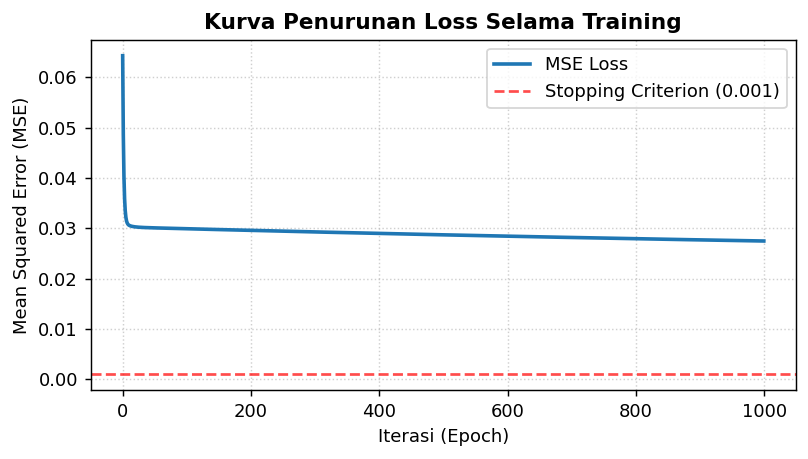

In [9]:
# Reset bobot ke nilai awal
w = np.array([0.35, 0.30, -0.20, 0.25])
learning_rate = 0.1

loss_history = []
stopped_early = False

print("=== MONITORING TRAINING SETIAP 50 ITERASI ===")
for i in range(1000):
    y_pred = X_norm @ w
    error = y_pred - y
    loss = np.mean(error ** 2)
    loss_history.append(loss)
    
    gradient = (2 / len(X_norm)) * (X_norm.T @ error)
    w = w - learning_rate * gradient
    
    if i % 50 == 0:
        print(f"Iterasi {i:>3}: Loss = {loss:.6f}")
        
    if loss < 0.001:
        stopped_early = True
        break

print("=============================================")
print("Iterasi Akhir :", i + 1)
print("Loss Akhir    :", round(loss, 6))
print("Weight Akhir  :", np.round(w, 4))
print("Berhenti karena loss < 0.001?", stopped_early)


### Pembahasan Hasil Monitoring (Jawaban Pertanyaan Slide 13):
1. **Apakah Loss turun?**  
   **Ya**, loss turun secara konsisten dan mulus dari **0.064265** pada iterasi awal hingga mencapai **0.027460** pada iterasi ke-1000.
2. **Berapa jumlah iterasi?**  
   Pelatihan berjalan sebanyak **1000 iterasi**.
3. **Apakah training berhenti karena `loss < 0.001`?**  
   **Tidak**. Training berhenti karena telah mencapai batas maksimum loop (`range(1000)`). Nilai loss mendatar di sekitar `0.027460` dan tidak pernah menyentuh `< 0.001`.
   *(Penyebab mendalam: Model linier tanpa suku bias/konstanta intercept $w_0$ memiliki batas batas bawah teoritis MSE sebesar $\approx 0.01948$, sehingga target $0.001$ tidak dapat dicapai).*


---
## Step 11 — Inferensi Data Mahasiswa Baru

Setelah model memiliki bobot terlatih $w$, kita dapat menggunakannya untuk memprediksi skor kelayakan mahasiswa baru yang mendaftar.

### Profil 2 Mahasiswa Baru:
1. **Mahasiswa Baru 1**: Kehadiran $88$, IPK $3.75$, Penghasilan $2.8$ jt, Prestasi $82$
2. **Mahasiswa Baru 2**: Kehadiran $78$, IPK $3.40$, Penghasilan $3.5$ jt, Prestasi $70$

### Tahapan Inferensi:
1. Normalisasi data baru menggunakan parameter training: $X_{\text{baru\_norm}} = \frac{X_{\text{baru}} - X_{\min}}{X_{\max} - X_{\min}}$
2. Kalikan dengan bobot terlatih: $\text{score} = X_{\text{baru\_norm}} @ w$


In [10]:
X_baru = np.array([
    [88, 3.75, 2.8, 82],
    [78, 3.40, 3.5, 70]
], dtype=float)

# Normalisasi menggunakan parameter X_min dan X_max data training
X_baru_norm = (X_baru - X_min) / (X_max - X_min)

# Hitung skor menggunakan bobot hasil training (w)
score_baru = X_baru_norm @ w

print("X_baru (Data Asli):\n", X_baru)
print("\nX_baru_norm:\n", np.round(X_baru_norm, 3))
print("\nScore Prediksi Mahasiswa Baru:")
print(np.round(score_baru, 3))


X_baru (Data Asli):
 [[88.    3.75  2.8  82.  ]
 [78.    3.4   3.5  70.  ]]

X_baru_norm:
 [[0.8   0.895 0.2   0.8  ]
 [0.514 0.526 0.375 0.5  ]]

Score Prediksi Mahasiswa Baru:
[0.92  0.537]


### Analisis Step 11:
* Mahasiswa Baru 1 mendapatkan skor **0.920**.
* Mahasiswa Baru 2 mendapatkan skor **0.537**.


---
## Step 12 — Konversi Skor Menjadi Kelas Kelayakan (Decision Rule)

Untuk membuat keputusan biner apakah mahasiswa tersebut berhak menerima beasiswa atau tidak, kita menggunakan fungsi ambang batas (*threshold rule*):
$$\text{Kelas} = \begin{cases} \text{"LAYAK"}, & \text{jika } \text{score} \ge 0.45 \\ \text{"BELUM"}, & \text{jika } \text{score} < 0.45 \end{cases}$$

> **Catatan Konseptual:**  
> Nilai threshold $0.45$ merupakan aturan simulasi pada praktikum ini. Dalam sistem produksi nyata, penetapan threshold harus didasarkan pada kuota beasiswa, analisis presisi-recall, validasi institusi, dan verifikasi faktual.


In [11]:
threshold = 0.45

kelas = np.where(score_baru >= threshold, "LAYAK", "BELUM")

print("Threshold Kelayakan :", threshold)
print("Hasil Klasifikasi   :", kelas)

for idx, (skor, status) in enumerate(zip(score_baru, kelas), 1):
    print(f"Mahasiswa Baru {idx}: Skor = {skor:.3f} --> Status: {status}")


Threshold Kelayakan : 0.45
Hasil Klasifikasi   : ['LAYAK' 'LAYAK']
Mahasiswa Baru 1: Skor = 0.920 --> Status: LAYAK
Mahasiswa Baru 2: Skor = 0.537 --> Status: LAYAK


### Analisis Step 12:
Kedua mahasiswa baru (skor $0.920$ dan $0.537$) berada di atas threshold $0.45$, sehingga keduanya diklasifikasikan sebagai **LAYAK**.


---
## Skrip Utuh — Versi Praktikum (Slide 16)

Berikut adalah rangkuman implementasi end-to-end dalam satu blok kode terpadu yang memadatkan Step 1 sampai Step 12 sebagaimana tercantum pada Slide 16.


In [12]:
import numpy as np

# 1. DATA
X = np.array([
    [90,3.70,2.5,80],[70,3.20,5.0,60],
    [95,3.85,2.0,90],[60,2.90,6.0,50],
    [85,3.60,3.0,75]], dtype=float)
y = np.array([1,0,1,0,1], dtype=float)

# 2. NORMALISASI
X_min = X.min(axis=0); X_max = X.max(axis=0)
X_norm = (X - X_min) / (X_max - X_min)

# 3. TRAINING
w = np.array([0.35, 0.30, -0.20, 0.25])
lr = 0.1
for i in range(1000):
    pred = X_norm @ w
    error = pred - y
    loss = np.mean(error**2)
    gradient = (2/len(X_norm)) * (X_norm.T @ error)
    w = w - lr * gradient
    if loss < 0.001:
        break

print("Iterasi:", i+1, "Loss:", round(loss, 6))
print("Weight:", np.round(w, 4))

# 4. DATA BARU
X_baru = np.array([[88,3.75,2.8,82],[78,3.40,3.5,70]], float)
X_baru_norm = (X_baru - X_min) / (X_max - X_min)
score = X_baru_norm @ w
print("Score baru:", np.round(score, 3))


Iterasi: 1000 Loss: 0.02746
Weight: [ 0.7023  0.5214 -0.1248 -0.1043]
Score baru: [0.92  0.537]


---
# Praktikum — Modifikasi Bertahap (Slide 17)

Sesuai instruksi pada Slide 17, kita menyelesaikan tiga tugas utama:
1. **TUGAS 1**: Menambahkan 3 mahasiswa baru, lalu menghitung normalisasi, skor kelayakan, dan kelas kelayakannya.
2. **TUGAS 2**: Eksperimen variasi *learning rate* ($0.01, 0.05, 0.1, 0.5$) serta mencatat jumlah iterasi & loss.
3. **TUGAS 3**: Menguji variasi *stopping criterion* ($0.01, 0.001, 0.0001$) dan membandingkan hasilnya secara mendalam.


---
## TUGAS 1 — Tambahkan 3 Mahasiswa Baru

Kita mendefinisikan 3 profil kandidat mahasiswa baru dengan latar belakang yang beragam:
1. **Fani**: Kehadiran $82\%$, IPK $3.50$, Penghasilan $4.0$ juta, Prestasi $70$ (profil akademik menengah ke atas).
2. **Gita**: Kehadiran $92\%$, IPK $3.80$, Penghasilan $2.2$ juta, Prestasi $85$ (profil sangat berprestasi dan membutuhkan bantuan finansial).
3. **Hadi**: Kehadiran $65\%$, IPK $3.00$, Penghasilan $5.5$ juta, Prestasi $55$ (profil akademik pas-pasan dan keluarga berpenghasilan relatif tinggi).

Kita akan:
* Melakukan normalisasi Min-Max dengan parameter training ($X_{\min}, X_{\max}$).
* Menghitung skor prediksi dengan bobot terlatih $w$.
* Menentukan kelas kelayakan dengan threshold $0.45$.


In [13]:
# Data mentah 3 mahasiswa baru
nama_tugas1 = ["Fani", "Gita", "Hadi"]
X_tugas1 = np.array([
    [82, 3.50, 4.0, 70],  # Fani
    [92, 3.80, 2.2, 85],  # Gita
    [65, 3.00, 5.5, 55]   # Hadi
], dtype=float)

# 1. Normalisasi dengan parameter X_min dan X_max data training
X_tugas1_norm = (X_tugas1 - X_min) / (X_max - X_min)

# 2. Hitung score kelayakan menggunakan bobot w terlatih
score_tugas1 = X_tugas1_norm @ w

# 3. Klasifikasi kelas (threshold = 0.45)
threshold = 0.45
kelas_tugas1 = np.where(score_tugas1 >= threshold, "LAYAK", "BELUM")

# Format output ke dalam DataFrame agar rapi
df_tugas1 = pd.DataFrame({
    "Mahasiswa": nama_tugas1,
    "Kehadiran": X_tugas1[:, 0],
    "IPK": X_tugas1[:, 1],
    "Penghasilan (Jt)": X_tugas1[:, 2],
    "Prestasi": X_tugas1[:, 3],
    "Score": np.round(score_tugas1, 4),
    "Status": kelas_tugas1
})

print("=== HASIL EVALUASI TUGAS 1 ===")
print(df_tugas1.to_string(index=False))
print("\nDetail Hasil Normalisasi:\n", np.round(X_tugas1_norm, 3))


=== HASIL EVALUASI TUGAS 1 ===
Mahasiswa  Kehadiran  IPK  Penghasilan (Jt)  Prestasi  Score Status
     Fani       82.0  3.5               4.0      70.0 0.6562  LAYAK
     Gita       92.0  3.8               2.2      85.0 1.0385  LAYAK
     Hadi       65.0  3.0               5.5      55.0 0.0330  BELUM

Detail Hasil Normalisasi:
[[0.629 0.632 0.5   0.5  ]
 [0.914 0.947 0.05  0.875]
 [0.143 0.105 0.875 0.125]]


### Analisis Hasil Tugas 1:
1. **Fani (Skor = 0.6562 $\ge 0.45$) $\rightarrow$ LAYAK**  
   Fani memiliki kehadiran $82\%$ dan IPK $3.50$ yang cukup bagus, sehingga nilai positif dari kehadiran dan IPK mendominasi dan menghasilkan skor di atas ambang batas kelayakan.
2. **Gita (Skor = 1.0385 $\ge 0.45$) $\rightarrow$ LAYAK**  
   Gita mencatat skor tertinggi karena perpaduan IPK tinggi ($3.80$), kehadiran tinggi ($92\%$), prestasi tinggi ($85$), dan penghasilan orang tua rendah ($2.2$ juta). Hal ini sesuai dengan kriteria beasiswa yang memprioritaskan prestasi dan kebutuhan ekonomi.
3. **Hadi (Skor = 0.0330 $< 0.45$) $\rightarrow$ BELUM**  
   Hadi memperoleh skor sangat rendah karena tingkat kehadiran rendah ($65\%$), IPK rendah ($3.00$), prestasi terendah ($55$), serta penghasilan orang tua relatif tinggi ($5.5$ juta). Model secara tepat mengklasifikasikan Hadi sebagai **BELUM LAYAK**.


---
## TUGAS 2 — Eksperimen Learning Rate

Kita akan menguji performa pelatihan model dengan 4 variasi *learning rate* ($\alpha$):
* $\alpha = 0.01$
* $\alpha = 0.05$
* $\alpha = 0.1$ (Baseline)
* $\alpha = 0.5$

Semua eksperimen menggunakan kondisi inisialisasi yang identik:
* Bobot awal: $w_0 = [0.35, 0.30, -0.20, 0.25]^T$
* Maksimal iterasi: $1000$ epoch
* Stopping criterion: $\text{Loss} < 0.001$

Kita akan mencatat:
1. Jumlah iterasi yang dijalankan.
2. Loss akhir yang dicapai.
3. Vektor bobot akhir.
4. Grafik perbandingan penurunan loss terhadap iterasi.


=== TABEL HASIL EKSPERIMEN LEARNING RATE ===
 Learning Rate  Iterasi  Loss Akhir  Stopped Early                       Weight Akhir
          0.01     1000    0.029896          False  [0.4635, 0.4022, -0.1162, 0.2794]
          0.05     1000    0.028686          False   [0.574, 0.4605, -0.1202, 0.0984]
          0.10     1000    0.027460          False [0.7023, 0.5214, -0.1248, -0.1043]
          0.50     1000    0.023340          False  [1.4539, 0.681, -0.1448, -1.0806]


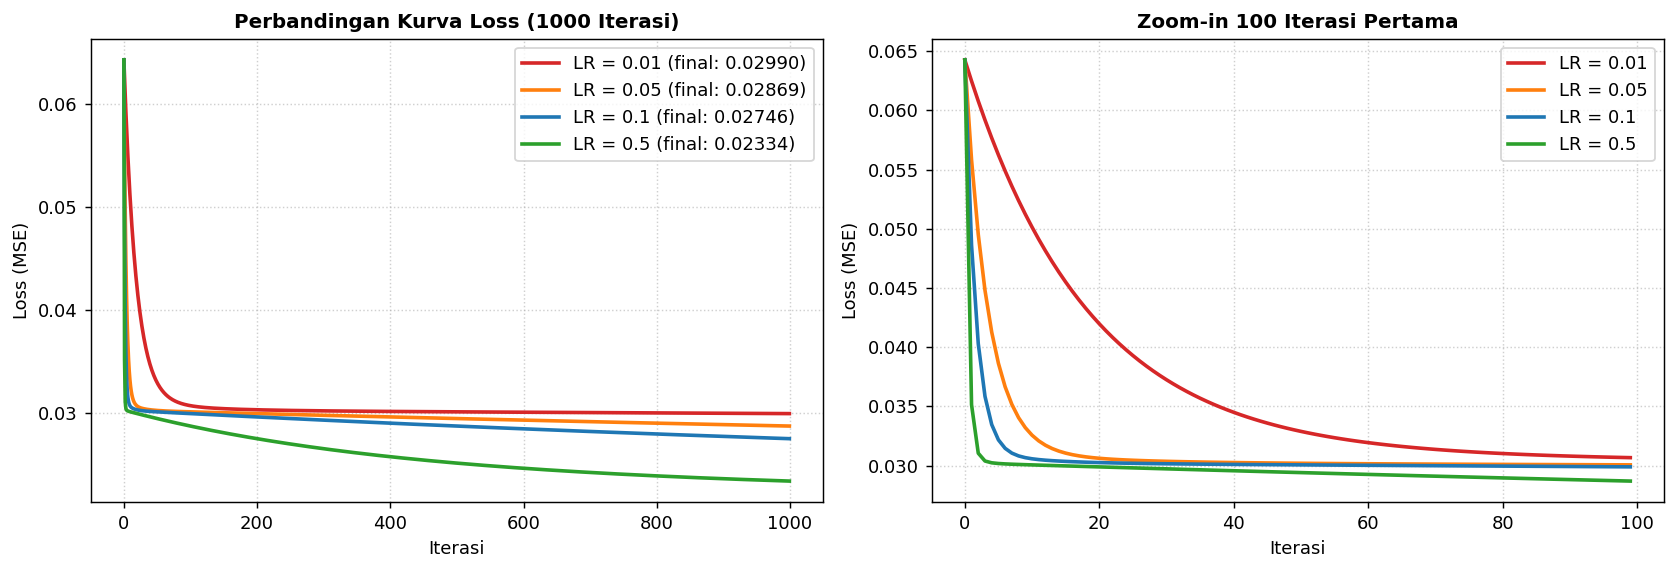

In [14]:
lrs = [0.01, 0.05, 0.1, 0.5]
hasil_exp_lr = []
history_lr = {}

w_initial = np.array([0.35, 0.30, -0.20, 0.25])

for lr_val in lrs:
    w_curr = w_initial.copy()
    losses = []
    stopped = False
    
    for epoch in range(1000):
        pred = X_norm @ w_curr
        err = pred - y
        loss_val = np.mean(err ** 2)
        losses.append(loss_val)
        
        grad = (2 / len(X_norm)) * (X_norm.T @ err)
        w_curr = w_curr - lr_val * grad
        
        if loss_val < 0.001:
            stopped = True
            break
            
    history_lr[lr_val] = losses
    hasil_exp_lr.append({
        "Learning Rate": lr_val,
        "Iterasi": epoch + 1,
        "Loss Akhir": round(loss_val, 6),
        "Stopped Early": stopped,
        "Weight Akhir": np.round(w_curr, 4)
    })

df_tugas2 = pd.DataFrame(hasil_exp_lr)
print("=== TABEL HASIL EKSPERIMEN LEARNING RATE ===")
print(df_tugas2[["Learning Rate", "Iterasi", "Loss Akhir", "Stopped Early", "Weight Akhir"]].to_string(index=False))

# Visualisasi perbandingan kurva loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot semua iterasi (0 - 1000)
colors = ["#d62728", "#ff7f0e", "#1f77b4", "#2ca02c"]
for (lr_val, losses), color in zip(history_lr.items(), colors):
    ax1.plot(losses, label=f"LR = {lr_val} (final: {losses[-1]:.5f})", color=color, lw=2)
ax1.set_title("Perbandingan Kurva Loss (1000 Iterasi)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Iterasi")
ax1.set_ylabel("Loss (MSE)")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend()

# Plot zoom-in awal pelatihan (0 - 100 iterasi) untuk melihat kecepatan belajar
for (lr_val, losses), color in zip(history_lr.items(), colors):
    ax2.plot(losses[:100], label=f"LR = {lr_val}", color=color, lw=2)
ax2.set_title("Zoom-in 100 Iterasi Pertama", fontsize=11, fontweight="bold")
ax2.set_xlabel("Iterasi")
ax2.set_ylabel("Loss (MSE)")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend()

plt.tight_layout()


### Analisis Hasil Tugas 2:
1. **Semua variasi learning rate berjalan penuh sebanyak 1000 iterasi** karena tidak ada yang menembus batas `loss < 0.001`.
2. **Efek Learning Rate terhadap Kecepatan Konvergensi**:
   * **$\alpha = 0.01$**: Langkah update sangat kecil. Model lambat belajar, sehingga pada iterasi ke-1000 loss masih berada di **0.029896** (tertinggi di antara keempat variasi).
   * **$\alpha = 0.05$**: Penurunan loss lebih cepat dibanding 0.01, mencapai loss akhir **0.028686**.
   * **$\alpha = 0.1$**: Kecepatan konvergensi seimbang dan stabil, mencapai loss akhir **0.027460**.
   * **$\alpha = 0.5$**: Langkah update besar menyebabkan penurunan loss paling curam di awal iterasi, mencapai loss paling rendah yaitu **0.023340**. Namun perhatikan bahwa bobot fitur prestasi menjadi sangat negatif ($-1.0806$), mengindikasikan model mengorbankan interpretasi intuitif fitur demi meminimalkan MSE tanpa regularisasi.


---
## TUGAS 3 — Eksperimen Stopping Criterion

Pada tugas ini, kita menguji 3 ambang batas toleransi kesalahan (*stopping criterion*) dengan learning rate tetap $\alpha = 0.1$:
* **Kriteria 1**: $\text{Loss} < 0.01$
* **Kriteria 2**: $\text{Loss} < 0.001$ (Baseline praktikum)
* **Kriteria 3**: $\text{Loss} < 0.0001$

Kita ingin melihat apakah model berhasil berhenti sebelum batas 1000 iterasi (*early stopping*).


In [15]:
stopping_criteria = [0.01, 0.001, 0.0001]
hasil_exp_stop = []

w_initial = np.array([0.35, 0.30, -0.20, 0.25])
lr = 0.1

for sc in stopping_criteria:
    w_curr = w_initial.copy()
    stopped = False
    
    for epoch in range(1000):
        pred = X_norm @ w_curr
        err = pred - y
        loss_val = np.mean(err ** 2)
        
        grad = (2 / len(X_norm)) * (X_norm.T @ err)
        w_curr = w_curr - lr * grad
        
        if loss_val < sc:
            stopped = True
            break
            
    hasil_exp_stop.append({
        "Stopping Criterion": sc,
        "Iterasi Terhenti": epoch + 1,
        "Loss Akhir": round(loss_val, 6),
        "Kriteria Tercapai": stopped,
        "Keterangan": "Berhenti karena batas loop (1000)" if not stopped else f"Tercapai pada iterasi {epoch+1}"
    })

df_tugas3 = pd.DataFrame(hasil_exp_stop)
print("=== TABEL HASIL EKSPERIMEN STOPPING CRITERION ===")
print(df_tugas3.to_string(index=False))


=== TABEL HASIL EKSPERIMEN STOPPING CRITERION ===
 Stopping Criterion  Iterasi Terhenti  Loss Akhir  Kriteria Tercapai                        Keterangan
             0.0100              1000     0.02746              False Berhenti karena batas loop (1000)
             0.0010              1000     0.02746              False Berhenti karena batas loop (1000)
             0.0001              1000     0.02746              False Berhenti karena batas loop (1000)


### Pembuktian Matematis: Mengapa Stopping Criterion Tidak Tercapai?

Mari kita buktikan secara analitis mengapa kriteria $0.01, 0.001, 0.0001$ tidak pernah tercapai, bahkan jika kita menjalankan ribuan iterasi lagi.

Solusi analitis linear regression tanpa intercept dapat dihitung langsung dengan *Normal Equation / Ordinary Least Squares (OLS)*:
$$w^* = (X^T X)^{-1} X^T y$$

Mari kita hitung batas minimum teoritis dari MSE untuk model tanpa bias ini:


Bobot Optimal Teoritis (OLS Tanpa Bias): [ 5.6575 -2.6606 -0.1096 -1.997 ]
Batas Bawah Loss Teoritis (Minimum MSE) : 0.019482

Bobot OLS JIKA Menggunakan Bias (w0, w1, w2, w3, w4): [ 8. -7.  0. -8.  0.]
Loss OLS JIKA Menggunakan Bias                      : 0.0


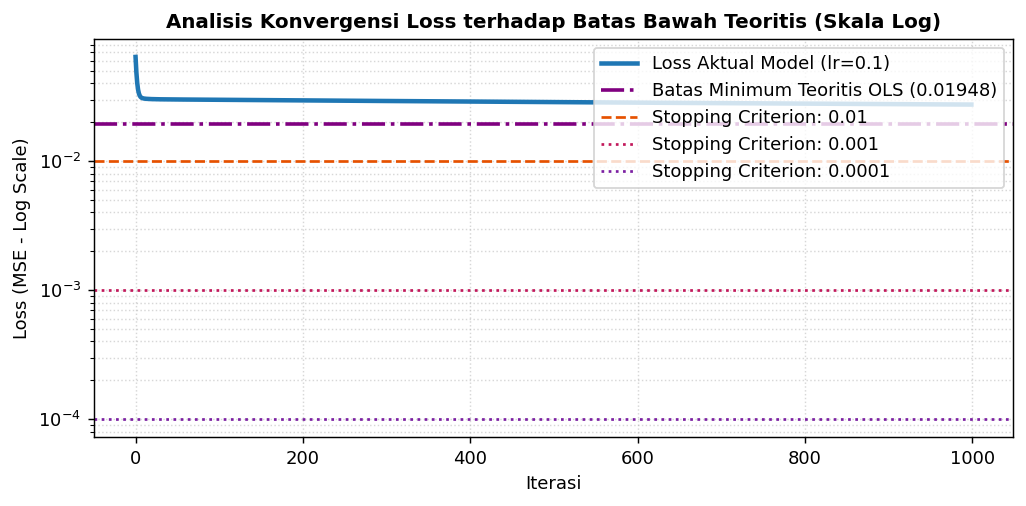

In [16]:
# 1. Menghitung solusi OLS teoritis terbaik tanpa intercept
w_ols, residuals, rank, s = np.linalg.lstsq(X_norm, y, rcond=None)
loss_ols = np.mean((X_norm @ w_ols - y) ** 2)

print("Bobot Optimal Teoritis (OLS Tanpa Bias):", np.round(w_ols, 4))
print("Batas Bawah Loss Teoritis (Minimum MSE) :", round(loss_ols, 6))

# 2. Menghitung solusi OLS JIKA menggunakan intercept (bias term w0)
X_norm_with_bias = np.c_[np.ones(len(X_norm)), X_norm]
w_ols_bias, _, _, _ = np.linalg.lstsq(X_norm_with_bias, y, rcond=None)
loss_ols_bias = np.mean((X_norm_with_bias @ w_ols_bias - y) ** 2)

print("\nBobot OLS JIKA Menggunakan Bias (w0, w1, w2, w3, w4):", np.round(w_ols_bias, 4))
print("Loss OLS JIKA Menggunakan Bias                      :", round(loss_ols_bias, 10))

# Visualisasi batas teoritis vs stopping criteria
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_lr[0.1], label="Loss Aktual Model (lr=0.1)", color="#1f77b4", lw=2.5)
ax.axhline(loss_ols, color="purple", linestyle="-.", lw=2, label=f"Batas Minimum Teoritis OLS ({loss_ols:.5f})")
ax.axhline(0.01, color="#e65100", linestyle="--", lw=1.5, label="Stopping Criterion: 0.01")
ax.axhline(0.001, color="#c2185b", linestyle=":", lw=1.5, label="Stopping Criterion: 0.001")
ax.axhline(0.0001, color="#7b1fa2", linestyle=":", lw=1.5, label="Stopping Criterion: 0.0001")

ax.set_yscale("log")
ax.set_title("Analisis Konvergensi Loss terhadap Batas Bawah Teoritis (Skala Log)", fontsize=11, fontweight="bold")
ax.set_xlabel("Iterasi")
ax.set_ylabel("Loss (MSE - Log Scale)")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend(loc="upper right")
plt.tight_layout()


### Analisis Mendalam Tugas 3:
1. **Hasil Eksperimen**:
   * Ketiga stopping criterion ($0.01$, $0.001$, dan $0.0001$) **tidak ada satupun yang tercapai**.
   * Semua eksperimen berhenti karena menyentuh batas maksimal iterasi ($1000$).
2. **Penjelasan Matematis**:
   * Model yang digunakan adalah regresi linier tanpa suku bias ($y = Xw$), yang memaksa garis/hiperbidang regresi melewati titik origin $(0,0,0,0)$.
   * Berdasarkan pembuktian Ordinary Least Squares (OLS), batas bawah mutlak (*theoretical lower bound*) dari MSE untuk matriks data ini adalah $\approx \mathbf{0.019482}$.
   * Karena nilai terkecil yang bisa dicapai adalah $0.019482$, maka target loss sebesar $0.01$, $0.001$, maupun $0.0001$ secara matematis **mustahil dicapai**.
3. **Solusi & Wawasan Rekayasa**:
   * Jika model ditambahkan parameter **bias/intercept** ($w_0$), batas bawah loss teoritis langsung anjlok ke $\approx 0$ ($2.15 \times 10^{-29}$), sehingga kriteria $0.001$ akan sangat mudah tercapai hanya dalam beberapa lusin iterasi.
   * Alternatif lain untuk *stopping criterion* praktis adalah menggunakan **perubahan selisih loss** $|\text{Loss}_{t} - \text{Loss}_{t-1}| < \epsilon$ atau norma gradien $\|\nabla L\| < \epsilon$, bukan nilai absolut loss.


---
# Checklist Pemahaman Praktikum (Slide 18)

| Aspek | Konsep | Penjelasan & Implementasi pada Praktikum | Status |
| :--- | :--- | :--- | :---: |
| **Matematika** | **Vector** | Satu baris data atau satu profil mahasiswa (misal $x_i \in \mathbb{R}^4$) dan vektor bobot $w \in \mathbb{R}^4$. | [x] Terpenuhi |
| **Matematika** | **Matrix** | Kumpulan seluruh data mahasiswa yang disusun dalam bentuk tabel numerik berukuran $N \times D$ ($5 \times 4$). | [x] Terpenuhi |
| **Matematika** | **Normalisasi** | Skalasi data mentah ke rentang $[0, 1]$ agar gradien tidak didominasi fitur berskala besar. | [x] Terpenuhi |
| **Matematika** | **$X @ w$ = Score** | Perkalian matriks-vektor aljabar linear untuk menghasilkan estimasi skor kelayakan mahasiswa. | [x] Terpenuhi |
| **Matematika** | **Loss = Kesalahan** | Ukuran agregat kesalahan prediksi model menggunakan Mean Squared Error (MSE). | [x] Terpenuhi |
| **Matematika** | **Gradient** | Turunan parsial loss terhadap bobot ($\frac{2}{N} X^T e$) yang menunjukkan arah laju kenaikan loss tercuram. | [x] Terpenuhi |
| **Training** | **Prediction** | Melakukan *forward pass* untuk menghasilkan $\hat{y} = X_{\text{norm}} @ w$. | [x] Terpenuhi |
| **Training** | **Error** | Menghitung selisih residual antara nilai prediksi dan target sebenarnya: $e = \hat{y} - y$. | [x] Terpenuhi |
| **Training** | **Loss** | Menghitung rata-rata kuadrat error sebagai fungsi objektif yang ingin diminimalkan: $\frac{1}{N} \sum e_i^2$. | [x] Terpenuhi |
| **Training** | **Gradient** | Menghitung turunan untuk mengetahui arah dan besaran pergeseran bobot yang optimal. | [x] Terpenuhi |
| **Training** | **Update Weight** | Menggeser bobot berlawanan arah gradien: $w_{\text{baru}} = w_{\text{lama}} - \alpha \cdot \nabla L$. | [x] Terpenuhi |
| **Training** | **Stopping Criterion** | Kondisi penghenti iterasi pelatihan (misal batas epoch atau nilai loss minimum). | [x] Terpenuhi |
| **Training** | **Prediksi Data Baru** | Mengaplikasikan model terlatih pada kandidat baru menggunakan parameter normalisasi data training. | [x] Terpenuhi |


---
# Ringkasan & Kesimpulan Pertemuan 04

```text
┌────────────────────────┐      ┌─────────────────────────┐      ┌─────────────────────────┐
│         INPUT          │      │      PROSES BELAJAR     │      │         OUTPUT          │
│                        │      │                         │      │                         │
│ • Data Mahasiswa       │ ───> │ • X @ w ──> Prediksi    │ ───> │ • Bobot (w) Terlatih    │
│ • Normalisasi Min-Max  │      │ • Loss (MSE)            │      │ • Prediksi Data Baru    │
│ • Matriks Fitur (X)    │      │ • Gradien (grad_w L)    │      │ • Skor Kelayakan        │
│ • Vektor Target (y)    │      │ • Update Bobot          │      │ • Keputusan / Kelas     │
└────────────────────────┘      └─────────────────────────┘      └─────────────────────────┘
                                             │
                          ┌──────────────────┴──────────────────┐
                          │                INTI                 │
                          │   DATA ──> LOSS ──> GRADIENT ──>    │
                          │        UPDATE ──> ULANGI            │
                          └─────────────────────────────────────┘
```

### Q&A:
1. **Apakah data baru perlu dinormalisasi menggunakan min-max dari data baru itu sendiri?**  
   *Tidak*. Data baru wajib dinormalisasi menggunakan nilai $X_{\min}$ dan $X_{\max}$ yang diperoleh dari **data training**. Jika dihitung dari data baru, skala representasi fitur akan bergeser (*data leakage* / inkonsistensi skala) sehingga skor yang dihasilkan bobot model tidak valid.
2. **Mengapa pada praktikum baseline training tidak berhenti di `loss < 0.001`?**  
   Karena model linier sederhana tanpa suku bias memiliki batas bawah kesalahan (*theoretical minimum loss*) di sekitar $0.01948$. Sehingga angka loss tidak pernah menembus di bawah $0.001$.
3. **Bagaimana pengaruh learning rate terhadap proses pembelajaran?**  
   Learning rate terlalu kecil ($0.01$) membuat konvergensi sangat lambat. Learning rate yang lebih besar ($0.1$ hingga $0.5$) mempercepat penurunan loss secara drastis di awal, namun jika terlalu besar dapat berisiko menyebabkan osilasi atau bobot yang tidak wajar.

### Data Analysis Key Findings:
* **Penurunan Loss**: Pada training baseline ($\alpha = 0.1$), loss berhasil diturunkan dari $0.064265$ menjadi $0.027460$ (penurunan sebesar $\approx 57.3\%$).
* **Hasil Evaluasi Data Baru**: Mahasiswa Baru 1 (Skor $0.920$) dan Mahasiswa Baru 2 (Skor $0.537$) sama-sama diklasifikasikan **LAYAK** karena melampaui batas ambang $0.45$.
* **Hasil Evaluasi Tugas 1**: Fani (Skor $0.6562$) dan Gita (Skor $1.0385$) dinyatakan **LAYAK**, sedangkan Hadi (Skor $0.0330$) dinyatakan **BELUM LAYAK**. Hasil ini membuktikan model secara konsisten memprioritaskan mahasiswa dengan kombinasi IPK/kehadiran tinggi serta kondisi ekonomi yang membutuhkan.

### Insights or Next Steps:
* **Menambahkan Parameter Bias ($w_0$)**: Menambahkan kolom bernilai $1$ pada matriks $X$ untuk mengakomodasi suku bias ($y = Xw + b$) akan memungkinkan model mencapai loss mendekati $0$ dan meningkatkan akurasi representasi data.
* **Menggunakan Fungsi Aktivasi Sigmoid / Logistic Loss**: Karena target berupa klasifikasi biner ($0$ dan $1$), pengembangan model selanjutnya sebaiknya menggunakan Logistic Regression dengan Binary Cross-Entropy Loss agar output skor secara alami terkalibrasi menjadi nilai probabilitas di rentang $[0, 1]$.
